# Dataset Description:

The dataset is built directly into the networkx Python library.

### Dataset Origins & Core Data:
The Davis Southern Women dataset is a classic bipartite (two-mode) network from a 1941 sociological study, mapping the attendance of 18 women at 14 informal social events over a nine-month period.

### Analytical Application:

It is heavily utilized in network analysis to test community detection algorithms and perform bipartite projections.

### Key Inferences:

The data allows analysts to infer social cliques among the women (based on overlapping attendance) and determine the structural similarity and social weight of the events.

### Bipartite Network Definition:

A graph where nodes are divided into two distinct, non-overlapping categories, and edges strictly connect nodes between these categories, never within them.

### Why the Dataset is Bipartite:

### Two Kind of Node Categories:

The network consists entirely of 18 "Women" nodes and 14 "Event" nodes.

### Strict Connection Rules:

Edges strictly represent attendance (connecting a Woman node to an Event node).

### No Direct Intra-Group Links:

The raw dataset contains zero edges between two women or between two events.

### Bipartite Projection:

To uncover direct relationships, analysis needed to perform a mathematical projection that folds the data into a standard one-mode graph, directly connecting women to one another based on the weighted number of shared events they attended.


In [ ]:
import networkx as nx

# Fetch the built-in Davis Southern Women bipartite graph
G = nx.davis_southern_women_graph()

# Separate the nodes into their two distinct bipartite groups for verification
women = [node for node, node_data in G.nodes(data=True) if node_data['bipartite'] == 0]
events = [node for node, node_data in G.nodes(data=True) if node_data['bipartite'] == 1]

print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")
print(f"Number of Women: {len(women)}")
print(f"Number of Events: {len(events)}")

Total Nodes: 32
Total Edges: 89
Number of Women: 18
Number of Events: 14


In [ ]:
import pandas as pd
import networkx as nx

# Fetch the bipartite dataset
G = nx.davis_southern_women_graph()

# Extract all the attendance records (edges)
edges = list(G.edges())

# Convert the edges into a flat list, then pivot into a clear table
df = pd.DataFrame(edges, columns=['Woman', 'Event'])
attendance_table = pd.crosstab(df['Woman'], df['Event'])

# Display the final incidence matrix in Colab
display(attendance_table)

Event,E1,E10,E11,E12,E13,E14,E2,E3,E4,E5,E6,E7,E8,E9
Woman,,,,,,,,,,,,,,
Brenda Rogers,1,0,0,0,0,0,0,1,1,1,1,1,1,0
Charlotte McDowd,0,0,0,0,0,0,0,1,1,1,0,1,0,0
Dorothy Murchison,0,0,0,0,0,0,0,0,0,0,0,0,1,1
Eleanor Nye,0,0,0,0,0,0,0,0,0,1,1,1,1,0
Evelyn Jefferson,1,0,0,0,0,0,1,1,1,1,1,0,1,1
Flora Price,0,0,1,0,0,0,0,0,0,0,0,0,0,1
Frances Anderson,0,0,0,0,0,0,0,1,0,1,1,0,1,0
Helen Lloyd,0,1,1,1,0,0,0,0,0,0,0,1,1,0
Katherina Rogers,0,1,0,1,1,1,0,0,0,0,0,0,1,1


# Finding Nodes and Connection:



In [ ]:
import networkx as nx

# Step 1: Fetch the dataset and explicitly define the two-mode structure
G = nx.davis_southern_women_graph()

# Isolate the two distinct modes (Women and Events) based on the bipartite attribute
women = [node for node, data in G.nodes(data=True) if data['bipartite'] == 0]
events = [node for node, data in G.nodes(data=True) if data['bipartite'] == 1]

print(f"Total Nodes: {G.number_of_nodes()} ({len(women)} Women, {len(events)} Events)")
print(f"Total Connections (Attendance): {G.number_of_edges()}")
print(f"Is strictly bipartite: {nx.is_bipartite(G)}")

Total Nodes: 32 (18 Women, 14 Events)
Total Connections (Attendance): 89
Is strictly bipartite: True


# Bipartite (Bimodel) Visualization:

The 18 women (blue circles on the left) and the 14 events (red squares on the right) make up the 32 total nodes.

We can trace exactly 89 gray lines representing the attendance records.

Notice that no gray line ever connects a blue circle to another blue circle, nor a red square to another red square which visually confirming the "strictly bipartite" rule where connections only cross between the two distinct groups.

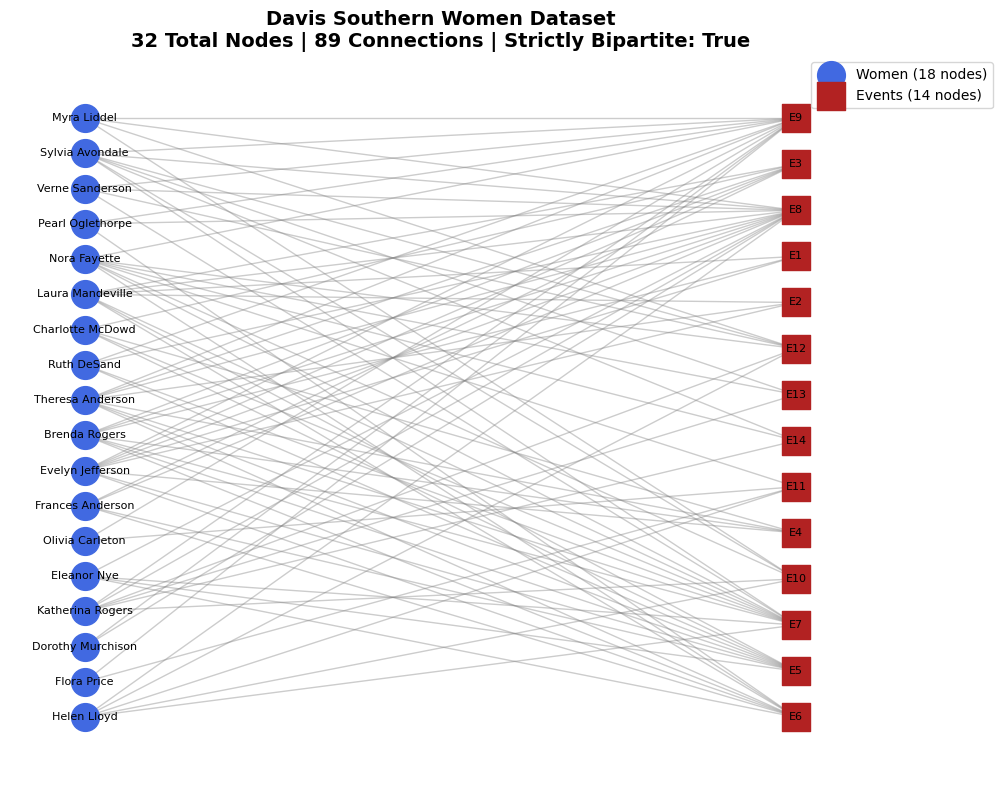

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Fetch the dataset and separate the node groups
G = nx.davis_southern_women_graph()
women = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
events = [n for n, d in G.nodes(data=True) if d['bipartite'] == 1]

# 2. Set up the plot and the specific bipartite layout
plt.figure(figsize=(10, 8))
pos = nx.bipartite_layout(G, women)

# 3. Draw the women nodes (blue circles on the left)
nx.draw_networkx_nodes(G, pos, nodelist=women, node_color='royalblue',
                       node_size=400, label='Women (18 nodes)')

# 4. Draw the event nodes (red squares on the right)
nx.draw_networkx_nodes(G, pos, nodelist=events, node_color='firebrick',
                       node_size=400, node_shape='s', label='Events (14 nodes)')

# 5. Draw the attendance connections
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

# 6. Add node names
nx.draw_networkx_labels(G, pos, font_size=8)

# 7. Add title, legend, and formatting
plt.title('Davis Southern Women Dataset\n32 Total Nodes | 89 Connections | Strictly Bipartite: True',
          fontsize=14, fontweight='bold')
plt.legend(scatterpoints=1, loc='upper right', bbox_to_anchor=(1.15, 1))
plt.axis('off')
plt.tight_layout()

# 8. Display the graph
plt.show()

# Newman’s weighted method

In [ ]:
import networkx as nx
from networkx.algorithms import bipartite

# 1. Fetch data and define node sets
G = nx.davis_southern_women_graph()
women = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
events = [n for n, d in G.nodes(data=True) if d['bipartite'] == 1]

# 2. Project the Women's Network (Newman's Method)
# Weights represent social closeness, adjusting for event size
W_newman = bipartite.collaboration_weighted_projected_graph(G, women)

# 3. Project the Events' Network (Newman's Method)
# Weights represent structural similarity, adjusting for the number of women who attended
E_newman = bipartite.collaboration_weighted_projected_graph(G, events)

print("=== WOMEN'S PROJECTED NETWORK ===")
print(f"Nodes: {W_newman.number_of_nodes()}, Edges: {W_newman.number_of_edges()}")
# Sort and display the top 5 strongest social ties among the women
top_women_ties = sorted(W_newman.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
for u, v, data in top_women_ties:
    print(f"Strongest Social Tie: {u} & {v} (Weight: {data['weight']:.2f})")

print("\n=== EVENTS' PROJECTED NETWORK ===")
print(f"Nodes: {E_newman.number_of_nodes()}, Edges: {E_newman.number_of_edges()}")
# Sort and display the top 5 most deeply connected events
top_event_ties = sorted(E_newman.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
for u, v, data in top_event_ties:
    print(f"Strongest Event Overlap: {u} & {v} (Weight: {data['weight']:.2f})")

=== WOMEN'S PROJECTED NETWORK ===
Nodes: 18, Edges: 139
Strongest Social Tie: Sylvia Avondale & Nora Fayette (Weight: 1.65)
Strongest Social Tie: Katherina Rogers & Sylvia Avondale (Weight: 1.62)
Strongest Social Tie: Evelyn Jefferson & Laura Mandeville (Weight: 1.56)
Strongest Social Tie: Katherina Rogers & Nora Fayette (Weight: 1.54)
Strongest Social Tie: Evelyn Jefferson & Theresa Anderson (Weight: 1.49)

=== EVENTS' PROJECTED NETWORK ===
Nodes: 14, Edges: 66
Strongest Event Overlap: E8 & E9 (Weight: 3.15)
Strongest Event Overlap: E9 & E11 (Weight: 2.14)
Strongest Event Overlap: E7 & E8 (Weight: 1.89)
Strongest Event Overlap: E6 & E8 (Weight: 1.79)
Strongest Event Overlap: E5 & E8 (Weight: 1.62)


# Inferences About the Women (Left Graph)The Core Cliques:

There are exceptionally thick lines connecting Theresa Anderson, Evelyn Jefferson, and Laura Mandeville, indicating a highly exclusive, close-knit friendship circle.

A second distinct clique forms at the bottom around Sylvia Avondale, Nora Fayette, and Katherina Rogers.   

# The Social Hubs:

Theresa Anderson and Evelyn Jefferson sit near the center of the network with many strong radiating lines, showing they are the most socially active leaders of the group.   

# The Periphery:

Flora Price and Olivia Carleton are pushed to the far bottom right with only faint, thin connections, meaning they are on the outskirts of this social scene.   

# Inferences About the Events (Right Graph) Nearly Identical Gatherings:

The thickest line on the board connects Event 8 (E8) and Event 9 (E9). This means almost the exact same guest list attended both of these specific gatherings.   

# The Season's Anchor Events:

Events E8, E9, E7, and E6 sit squarely in the middle of the web with multiple thick connections.

These were likely the major functions that successfully drew attendees from various distinct cliques.   

# Niche/Exclusive Events:

Events like E1, E13, and E14 sit on the far outer edges with very weak connections, indicating they were likely small, intimate, or isolated gatherings.

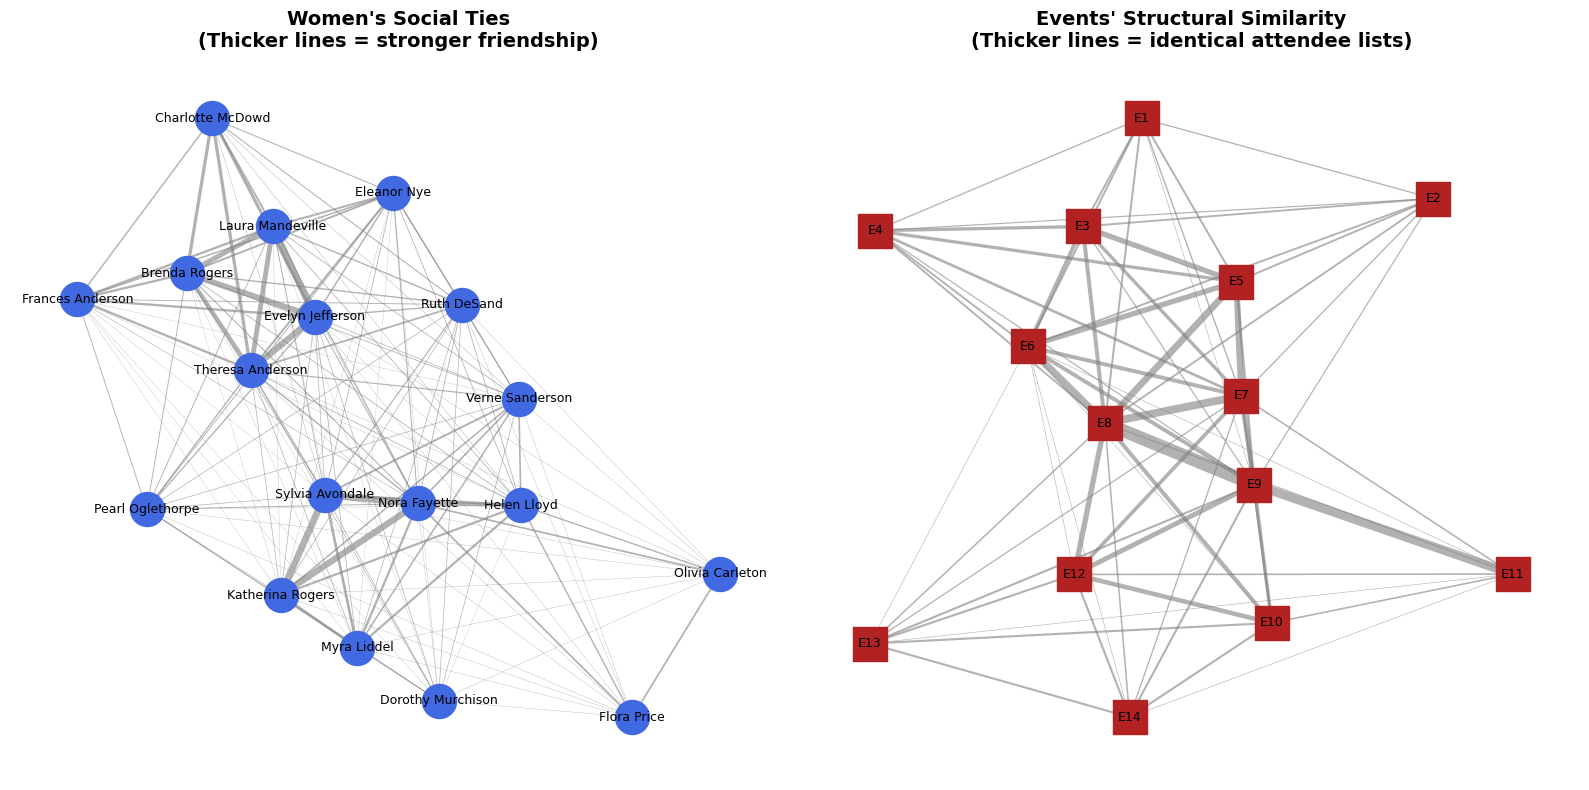

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a wide figure to hold two graphs side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Plot 1: Women's Projected Network ---
# Extract the Newman weights and multiply by a scaling factor for visual thickness
women_edges = W_newman.edges(data=True)
women_weights = [data['weight'] * 3 for u, v, data in women_edges]

pos_w = nx.spring_layout(W_newman, seed=42) # Seed ensures the layout stays consistent
nx.draw_networkx_nodes(W_newman, pos_w, ax=axes[0], node_color='royalblue', node_size=600)
nx.draw_networkx_edges(W_newman, pos_w, ax=axes[0], width=women_weights, edge_color='gray', alpha=0.6)
nx.draw_networkx_labels(W_newman, pos_w, ax=axes[0], font_size=9)

axes[0].set_title("Women's Social Ties\n(Thicker lines = stronger friendship)", fontsize=14, fontweight='bold')
axes[0].axis('off')

# --- Plot 2: Events' Projected Network ---
# Extract weights and scale for visual thickness
event_edges = E_newman.edges(data=True)
event_weights = [data['weight'] * 3 for u, v, data in event_edges]

pos_e = nx.spring_layout(E_newman, seed=42)
nx.draw_networkx_nodes(E_newman, pos_e, ax=axes[1], node_color='firebrick', node_size=600, node_shape='s')
nx.draw_networkx_edges(E_newman, pos_e, ax=axes[1], width=event_weights, edge_color='gray', alpha=0.6)
nx.draw_networkx_labels(E_newman, pos_e, ax=axes[1], font_size=9)

axes[1].set_title("Events' Structural Similarity\n(Thicker lines = identical attendee lists)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Calculating Centrality Metrics (Degree & Betweenness)

### Interpreting the Women's CentralityThe Core Brokers:

Evelyn Jefferson, Theresa Anderson, Sylvia Avondale, Verne Sanderson, Ruth DeSand, Nora Fayette, and Helen Lloyd all share a perfect degree centrality of 1.000000 and the highest betweenness score of 0.010122.

This mathematically confirms they are the ultimate "brokers" of the dataset, successfully attending the most events and acting as the vital bridges holding the entire social network together.   

The Middle Tier: Women like Myra Liddel and Katherina Rogers have lower betweenness scores (0.005348), meaning they are well-connected but less critical for bridging distinct cliques.   

The Isolated Periphery: Charlotte McDowd, Olivia Carleton, and Flora Price sit at the very bottom of the social hierarchy with a betweenness score of exactly 0.000000. This means they hold no bridging influence whatsoever and rely entirely on the core brokers to connect them to the broader group.

### Interpreting the Events' CentralityThe Season's Anchor Events:

Events E6, E7, E8, and E9 dominate the calendar with perfect degree centrality (1.000000) and the highest bridging scores (0.080128).

These four gatherings were the undeniable centerpieces of the nine-month season, successfully drawing attendees across all cliques.   

Niche Gatherings: Every single other event (E1 through E5, and E10 through E14) has a betweenness score of exactly 0.000000.

This stark drop-off reveals that these 10 events were highly localized, intimate, or niche gatherings that did not serve to bridge different social circles together.   

In [ ]:
import pandas as pd
import networkx as nx

# Calculate metrics for the Women's Network
deg_cen_women = nx.degree_centrality(W_newman)
bet_cen_women = nx.betweenness_centrality(W_newman)

# Compile women's metrics into a table, sorted by the highest broker score
women_df = pd.DataFrame({
    'Degree Centrality': deg_cen_women,
    'Betweenness (Broker Score)': bet_cen_women
}).sort_values(by='Betweenness (Broker Score)', ascending=False)

print("=== ALL 18 WOMEN: CENTRALITY METRICS ===")
# By removing .head(), Colab will output the entire list of 18 women
display(women_df)

=== ALL 18 WOMEN: CENTRALITY METRICS ===


,Degree Centrality,Betweenness (Broker Score)
Evelyn Jefferson,1.000000,0.010122
Theresa Anderson,1.000000,0.010122
Sylvia Avondale,1.000000,0.010122
Verne Sanderson,1.000000,0.010122
Ruth DeSand,1.000000,0.010122
Nora Fayette,1.000000,0.010122
Helen Lloyd,1.000000,0.010122
Myra Liddel,0.941176,0.005348
Katherina Rogers,0.941176,0.005348
Pearl Oglethorpe,0.941176,0.005348


In [ ]:
import pandas as pd
import networkx as nx

# Calculate metrics for the Events' Network
deg_cen_events = nx.degree_centrality(E_newman)
bet_cen_events = nx.betweenness_centrality(E_newman)

# Compile events' metrics into a table, sorted by the highest attendance draw
events_df = pd.DataFrame({
    'Degree Centrality': deg_cen_events,
    'Betweenness (Bridge Score)': bet_cen_events
}).sort_values(by='Degree Centrality', ascending=False)

print("=== ALL 14 EVENTS: CENTRALITY METRICS ===")
# By removing .head(), Colab will output the entire list of 14 events
display(events_df)

=== ALL 14 EVENTS: CENTRALITY METRICS ===


,Degree Centrality,Betweenness (Bridge Score)
E6,1.000000,0.080128
E7,1.000000,0.080128
E8,1.000000,0.080128
E9,1.000000,0.080128
E2,0.615385,0.000000
E1,0.615385,0.000000
E5,0.615385,0.000000
E4,0.615385,0.000000
E3,0.615385,0.000000
E10,0.615385,0.000000


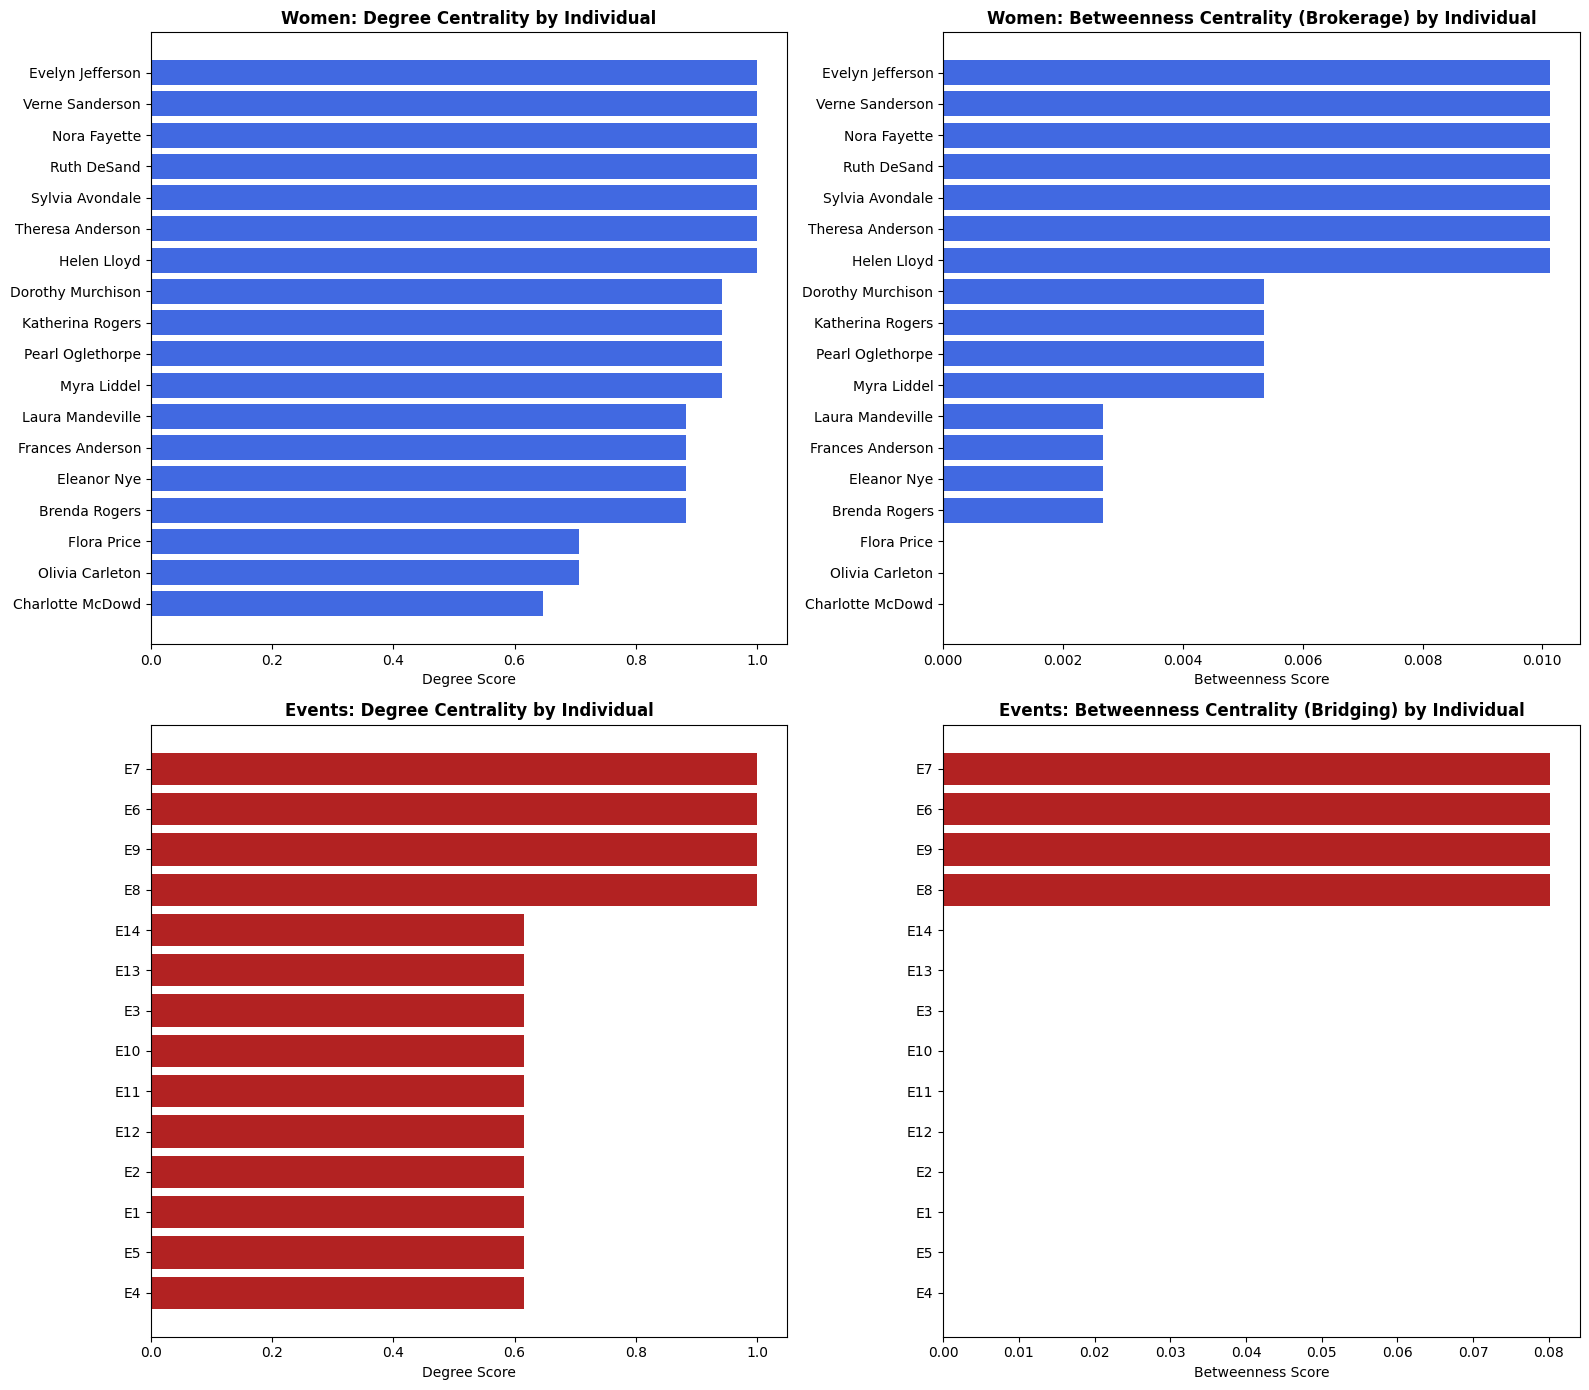

In [16]:
import matplotlib.pyplot as plt

# Create a 2x2 grid for our individual bar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Sort the dataframes so the highest scores appear at the top of the horizontal charts
women_deg_sorted = women_df.sort_values(by='Degree Centrality', ascending=True)
women_bet_sorted = women_df.sort_values(by='Betweenness (Broker Score)', ascending=True)
events_deg_sorted = events_df.sort_values(by='Degree Centrality', ascending=True)
events_bet_sorted = events_df.sort_values(by='Betweenness (Bridge Score)', ascending=True)

# --- Top Row: Women's Individual Centrality ---
# 1. Women - Degree Centrality
axes[0, 0].barh(women_deg_sorted.index, women_deg_sorted['Degree Centrality'], color='royalblue')
axes[0, 0].set_title("Women: Degree Centrality by Individual", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Degree Score")

# 2. Women - Betweenness Centrality
axes[0, 1].barh(women_bet_sorted.index, women_bet_sorted['Betweenness (Broker Score)'], color='royalblue')
axes[0, 1].set_title("Women: Betweenness Centrality (Brokerage) by Individual", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Betweenness Score")

# --- Bottom Row: Events' Individual Centrality ---
# 3. Events - Degree Centrality
axes[1, 0].barh(events_deg_sorted.index, events_deg_sorted['Degree Centrality'], color='firebrick')
axes[1, 0].set_title("Events: Degree Centrality by Individual", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Degree Score")

# 4. Events - Betweenness Centrality
axes[1, 1].barh(events_bet_sorted.index, events_bet_sorted['Betweenness (Bridge Score)'], color='firebrick')
axes[1, 1].set_title("Events: Betweenness Centrality (Bridging) by Individual", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Betweenness Score")

# Adjust layout for clean reading
plt.tight_layout()
plt.show()

# Interpretation Women's Cliques:

The Two Women's Cliques (Blue vs. Green)The modularity algorithm successfully split the women into two distinct primary social circles: Clique 1 (blue) and Clique 2 (green).   

Within Clique 1, the tightest, heavily weighted friendship triangle exists between Evelyn Jefferson, Laura Mandeville (1.56 weight), and Theresa Anderson.   

Within Clique 2, the strongest social bonds are between Sylvia Avondale, Nora Fayette (1.65 weight), and Katherina Rogers (1.62 weight).   

Women like Flora Price, Olivia Carleton, and Eleanor Nye float without any strong connections (weights greater than 0.5) to either core group.   



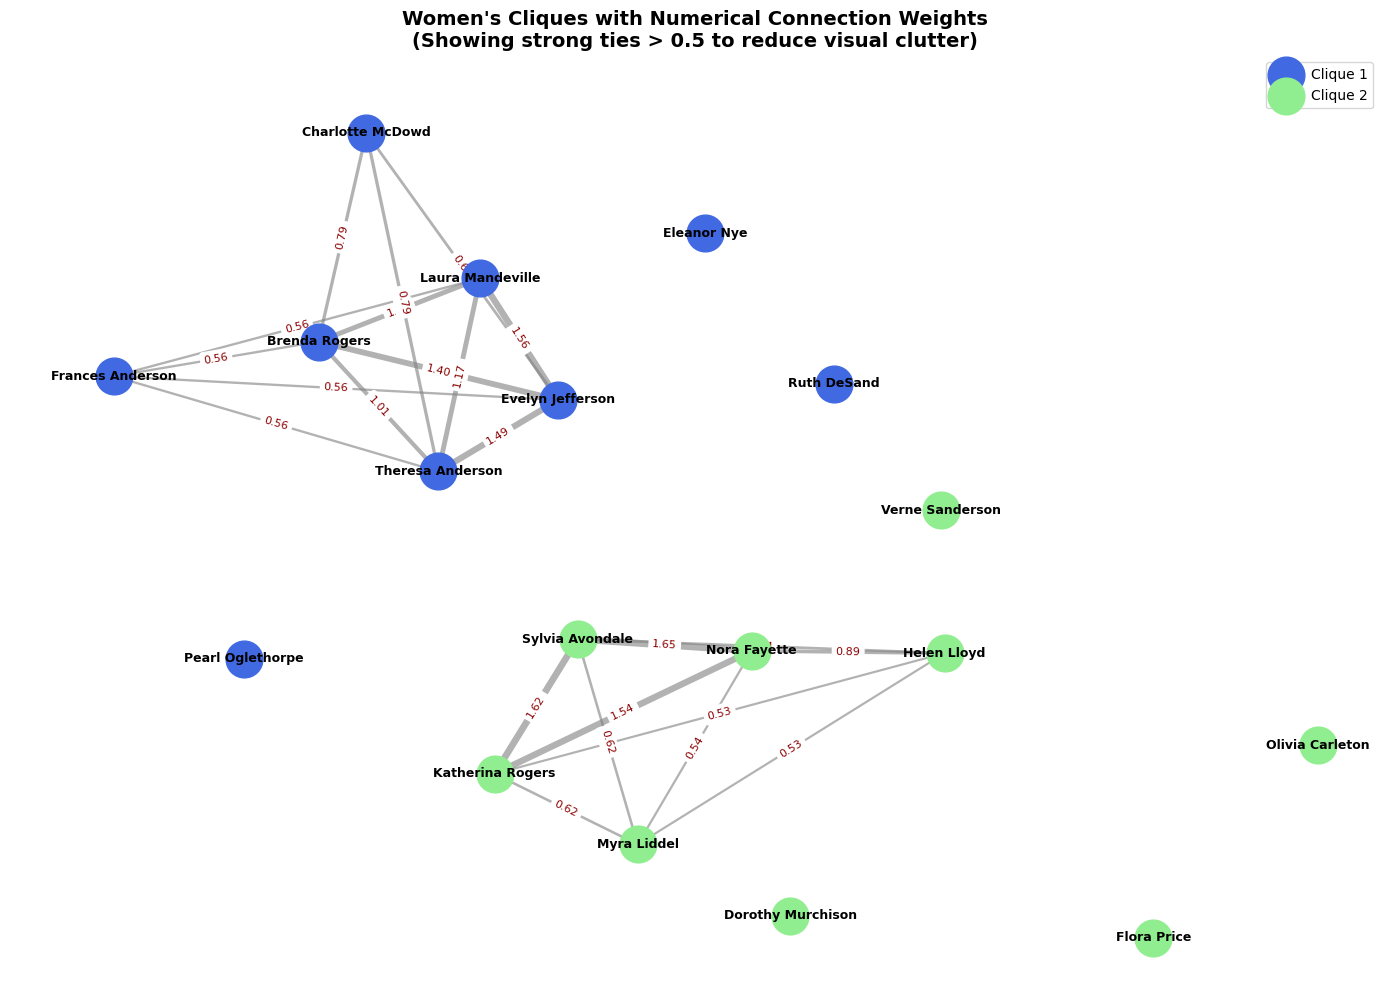

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Set up the plot layout
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(W_newman, seed=42) # Consistent spacing

# 1. Color-code the women based on the detected cliques from Step 4
colors = ['royalblue', 'lightgreen', 'lightcoral', 'gold']
for i, clique in enumerate(women_cliques):
    nx.draw_networkx_nodes(W_newman, pos, nodelist=list(clique),
                           node_color=colors[i % len(colors)], node_size=700,
                           label=f'Clique {i+1}')

# 2. Filter for readable connections (only showing weights > 0.5)
strong_edges = [(u, v) for u, v, d in W_newman.edges(data=True) if d['weight'] > 0.5]
strong_weights = [d['weight'] * 3 for u, v, d in W_newman.edges(data=True) if d['weight'] > 0.5]

# Draw the lines matching the strength of the tie
nx.draw_networkx_edges(W_newman, pos, edgelist=strong_edges, width=strong_weights,
                       alpha=0.6, edge_color='gray')

# Add the women's names
nx.draw_networkx_labels(W_newman, pos, font_size=9, font_weight='bold')

# 3. Attach the exact numerical weight labels directly onto the lines
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in W_newman.edges(data=True) if d['weight'] > 0.5}
nx.draw_networkx_edge_labels(W_newman, pos, edge_labels=edge_labels, font_size=8, font_color='darkred')

# Format and display
plt.title("Women's Cliques with Numerical Connection Weights\n(Showing strong ties > 0.5 to reduce visual clutter)",
          fontsize=14, fontweight='bold')
plt.legend(scatterpoints=1, loc='upper right')
plt.axis('off')
plt.tight_layout()
plt.show()

# Interpretation Event Groups:

Overlap:  (represented by the numerical weight and line thickness) measures how identical the guest lists were between any two events.   

High Overlap (Nearly Identical Crowds): Look at the thick line between E8 and E9, which has a massive score of 3.15.

This means that almost the exact same specific group of women attended both gatherings. Socially, these two parties catered to the exact same clique. Another strong example is E9 and E11 with a score of 2.14.   

Moderate Overlap (Shared Attendees): The connections between E7 and E8 (score 1.89) or E6 and E8 (score 1.79) show a moderate overlap. A solid core of women attended both, but the guest lists still had notable differences.   

Low/Zero Overlap (Distinct Crowds): Lines with low scores like 0.51 (e.g., between E13 and E14 or E12 and E13) indicate that only a very small fraction of women attended both.

Furthermore, an isolated event like E2 has no visible connections in this filtered graph, meaning its guest list had virtually zero meaningful overlap with the other major events of the season.   

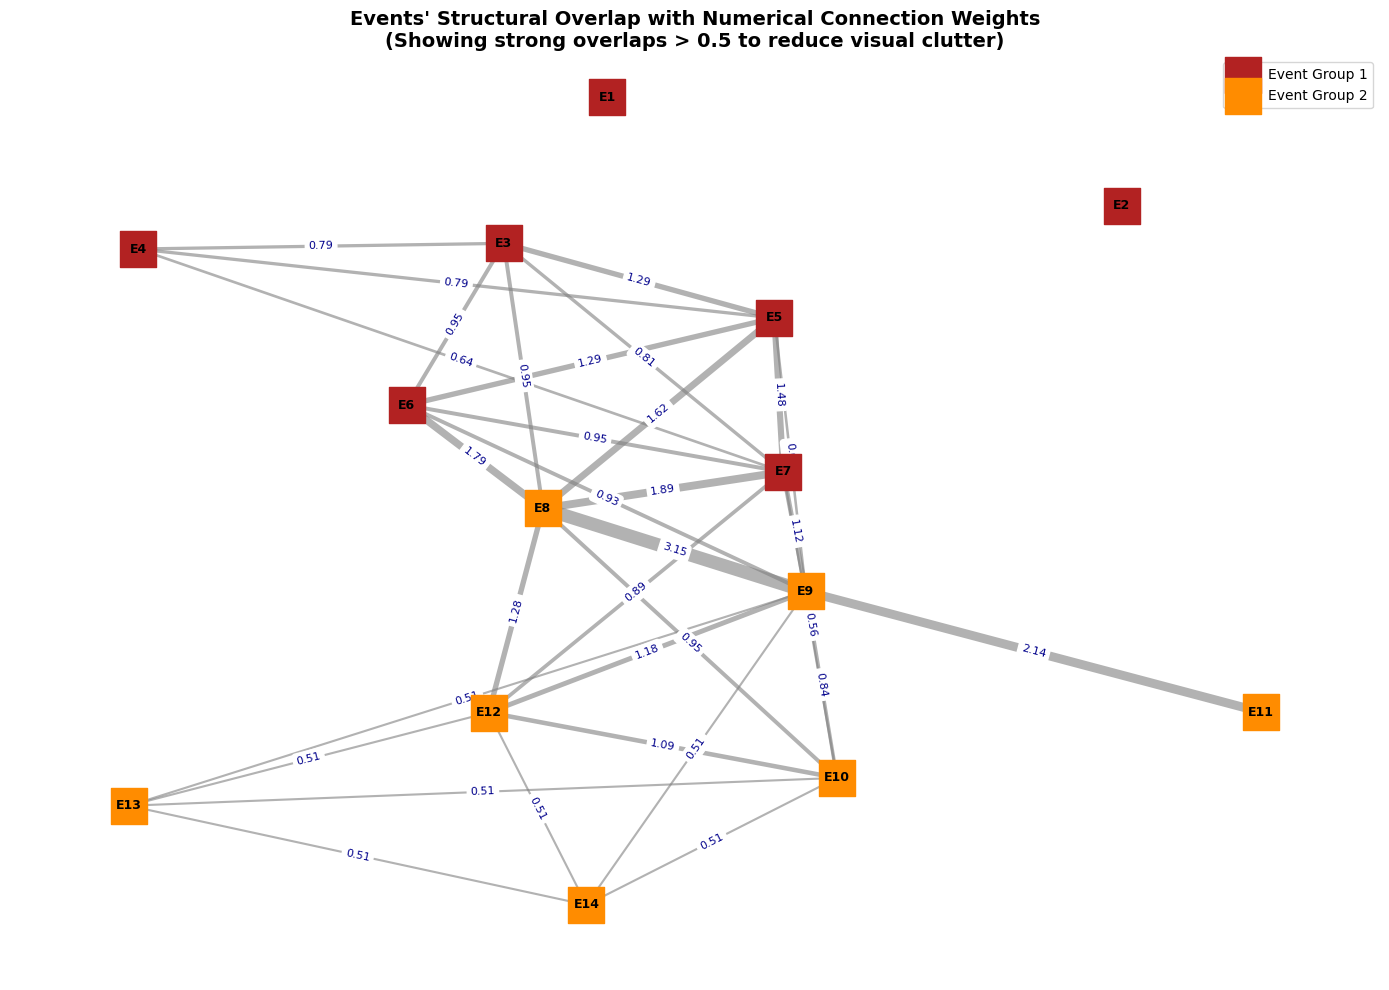

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Set up the plot layout for the events
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(E_newman, seed=42)

# 1. Color-code the events based on the detected groupings from Step 4
colors = ['firebrick', 'darkorange', 'purple', 'teal']
for i, group in enumerate(event_groups):
    nx.draw_networkx_nodes(E_newman, pos, nodelist=list(group),
                           node_color=colors[i % len(colors)], node_size=700,
                           node_shape='s', label=f'Event Group {i+1}')

# 2. Filter for readable connections (showing weights > 0.5)
strong_event_edges = [(u, v) for u, v, d in E_newman.edges(data=True) if d['weight'] > 0.5]
strong_event_weights = [d['weight'] * 3 for u, v, d in E_newman.edges(data=True) if d['weight'] > 0.5]

# Draw the lines matching the strength of the overlap
nx.draw_networkx_edges(E_newman, pos, edgelist=strong_event_edges, width=strong_event_weights,
                       alpha=0.6, edge_color='gray')

# Add the event names (E1, E2, etc.)
nx.draw_networkx_labels(E_newman, pos, font_size=9, font_weight='bold')

# 3. Attach the exact numerical weight labels directly onto the lines
event_edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in E_newman.edges(data=True) if d['weight'] > 0.5}
nx.draw_networkx_edge_labels(E_newman, pos, edge_labels=event_edge_labels, font_size=8, font_color='darkblue')

# Format and display
plt.title("Events' Structural Overlap with Numerical Connection Weights\n(Showing strong overlaps > 0.5 to reduce visual clutter)",
          fontsize=14, fontweight='bold')
plt.legend(scatterpoints=1, loc='upper right')
plt.axis('off')
plt.tight_layout()
plt.show()